imports

In [1]:
#dataanalyse
import numpy as np 
import pandas as pd 

#plotting
import seaborn as sns 
import missingno as msno 
import matplotlib.pyplot as plt 

#preprocessing 
from sklearn.preprocessing import LabelEncoder

#maskinlæring
import xgboost as xgb 

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from xgboost import XGBRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# metrics
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold


Navnkonvensjon i datasettet
features i lignende grupperinger er merket med det i feature navnet:
-ind
-reg
-car
-calc
og de er etterfulgt av _bin og _cat for hhvs. binære og kategoriske verdier. Kolonner uten disse markeringene er kontinuerlige eller ordinale(?). I det originale datasettet er Nan verdier byttet med -1, men dette bytter jeg senere. Target kolonnen er binær data som sier om det ble gjort et forsikringskrav eller ikke for personen.

<!-- Data loading -->

In [60]:
df_train = pd.read_csv('C:/Users/fredr/OneDrive/Skrivebord/insurancemodel/data/raw/train.csv')
df_test = pd.read_csv('C:/Users/fredr/OneDrive/Skrivebord/insurancemodel/data/raw/test.csv')
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_bin   59521

target
0    573518
1     21694
Name: count, dtype: int64


Positive rate: 3.645%
Negative rate: 96.355%


has -1 values: ps_ind_02_cat
has -1 values: ps_ind_04_cat
has -1 values: ps_ind_05_cat
has -1 values: ps_reg_03
has -1 values: ps_car_01_cat
has -1 values: ps_car_02_cat
has -1 values: ps_car_03_cat
has -1 values: ps_car_05_cat
has -1 values: ps_car_07_cat
has -1 values: ps_car_09_cat
has -1 values: ps_car_11
has -1 values: ps_car_12
has -1 values: ps_car_14


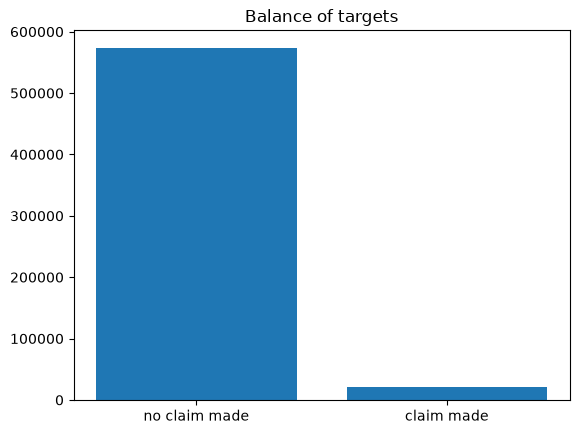

In [83]:
targets = df_train['target'].value_counts(dropna=False)
print(targets)
claim_percentage = np.mean(df_train['target'])
no_claim_percentage = 1-claim_percentage

print('\n')

targets["no claim made"]=targets.pop(0)
targets["claim made"]=targets.pop(1)
plt.bar(list(targets.keys()),list(targets.values))
plt.title("Balance of targets")



print(f"Positive rate: {claim_percentage*100:.3f}%")
print(f"Negative rate: {no_claim_percentage*100:.3f}%")

print('\n')
missing_value_columns = []
for k in df_train.columns:
    if df_train[k].value_counts(dropna=False).get(-1):
        print(f"has -1 values: {k}")
        missing_value_columns.append(k)
        


Clearly, the data is inbalanced.\n

La oss se på metadata.

In [64]:
def get_meta(df):
    data = []
    for col in df.columns:
        if col=='target':
            role = 'target'
        elif col=='id':
            role = 'id'
        else:
            role = 'input'

        if 'bin' in col or col=='target':
            level = 'binary'
        elif 'cat' in col or col=='id':
            level = 'nominal'
        elif df[col].dtype == np.float64:
            level = 'interval' 
        elif df[col].dtype == np.int64:
            level = 'ordinal'

        keep = True 
        if col=='id':
            keep = False 

        dtype = df[col].dtype

        col_dict ={
            'varname':col,
            'role':role,
            'level':level,
            'keep':keep,
            'dtype':dtype
        }
        data.append(col_dict)
    meta = pd.DataFrame(data, columns = ['varname', 'role','level','keep','dtype'])
    meta.set_index('varname', inplace=True)
    return meta

meta_data = get_meta(df_train)
print(meta_data)

                  role     level   keep    dtype
varname                                         
id                  id   nominal  False    int64
target          target    binary   True    int64
ps_ind_01        input   ordinal   True    int64
ps_ind_02_cat    input   nominal   True    int64
ps_ind_03        input   ordinal   True    int64
ps_ind_04_cat    input   nominal   True    int64
ps_ind_05_cat    input   nominal   True    int64
ps_ind_06_bin    input    binary   True    int64
ps_ind_07_bin    input    binary   True    int64
ps_ind_08_bin    input    binary   True    int64
ps_ind_09_bin    input    binary   True    int64
ps_ind_10_bin    input    binary   True    int64
ps_ind_11_bin    input    binary   True    int64
ps_ind_12_bin    input    binary   True    int64
ps_ind_13_bin    input    binary   True    int64
ps_ind_14        input   ordinal   True    int64
ps_ind_15        input   ordinal   True    int64
ps_ind_16_bin    input    binary   True    int64
ps_ind_17_bin    inp

Text(0.5, 1.0, 'variabletype fordeling')

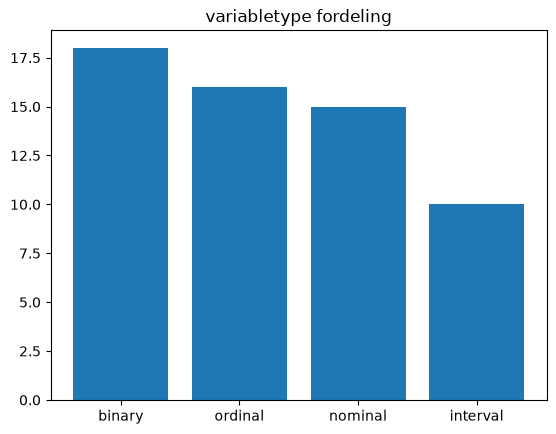

In [73]:
meta_value_counts = meta_data['level'].value_counts()

plt.bar(meta_value_counts.keys(), meta_value_counts.values)
plt.title("variabletype fordeling")


In [74]:
col_ordinal   = meta_data[(meta_data.level == 'ordinal') & (meta_data.keep)].index
col_nominal   = meta_data[(meta_data.level == 'nominal') & (meta_data.keep)].index
col_internval = meta_data[(meta_data.level == 'interval') & (meta_data.keep)].index
col_binary    = meta_data[(meta_data.level == 'binary') & (meta_data.keep) & (meta_data.role != 'target')].index

La oss først se på de kontinuerlige om vi kan finne noen korrelasjoner

Index(['ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_12', 'ps_car_13',
       'ps_car_14', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03'],
      dtype='str', name='varname')

,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03
ps_reg_01,1.000000,0.471027,0.637035,0.018802,0.027097,0.012704,0.002765,-0.000891,0.002194,-0.001538
ps_reg_02,0.471027,1.000000,0.516457,0.171416,0.194316,0.004147,0.054510,0.001347,-0.000770,0.000022
ps_reg_03,0.637035,0.516457,1.000000,0.082578,0.099415,0.006271,0.022930,-0.001484,0.002147,-0.000401
ps_car_12,0.018802,0.171416,0.082578,1.000000,0.671720,0.012395,0.049882,-0.000700,-0.000427,0.000172
ps_car_13,0.027097,0.194316,0.099415,0.671720,1.000000,-0.037310,0.529519,0.000157,0.000040,-0.000200
ps_car_14,0.012704,0.004147,0.006271,0.012395,-0.037310,1.000000,-0.033060,-0.001191,0.001217,0.000433
ps_car_15,0.002765,0.054510,0.022930,0.049882,0.529519,-0.033060,1.000000,0.000344,-0.000252,-0.001043
ps_calc_01,-0.000891,0.001347,-0.001484,-0.000700,0.000157,-0.001191,0.000344,1.000000,-0.002418,0.000526
ps_calc_02,0.002194,-0.000770,0.002147,-0.000427,0.000040,0.001217,-0.000252,-0.002418,1.000000,0.002948
ps_calc_03,-0.001538,0.000022,-0.000401,0.000172,-0.000200,0.000433,-0.001043,0.000526,0.002948,1.000000


<Axes: >

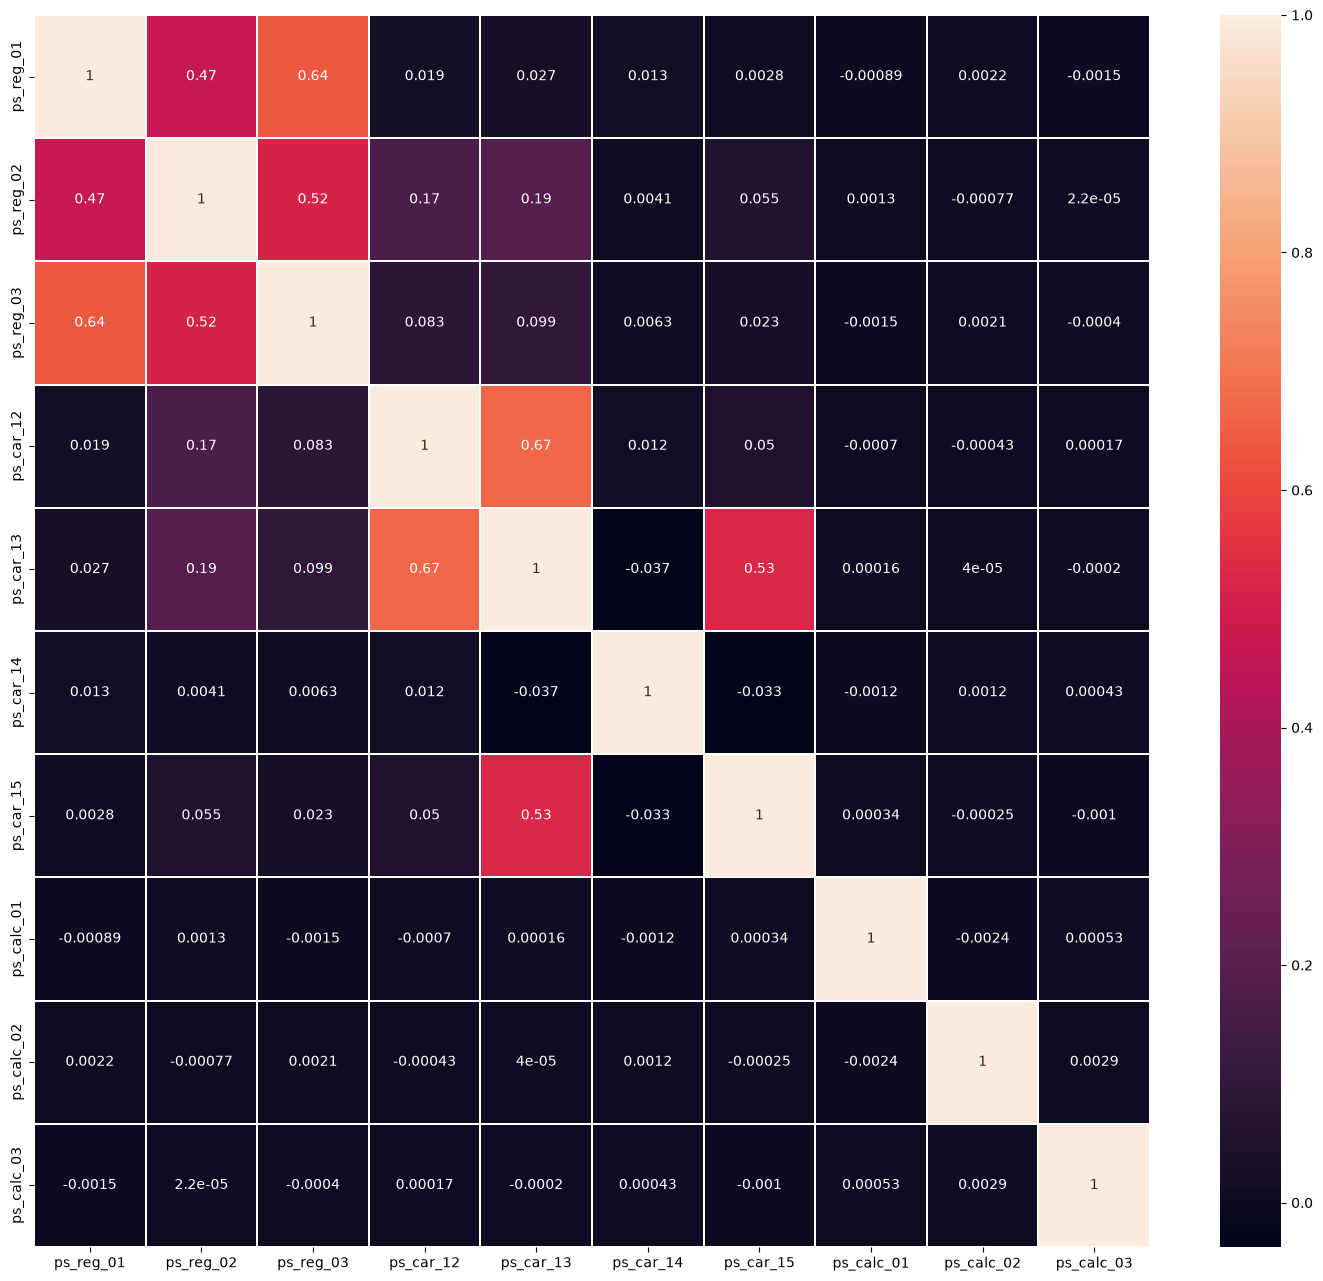

In [82]:
display(col_internval)
corr_matrix = df_train[col_internval].corr()
display(corr_matrix)

plt.figure(figsize=(18,16))
sns.heatmap(corr_matrix, annot=True, linewidths=.1)

Korrelasjon mellom manglende verdier kanskje?


<Axes: >

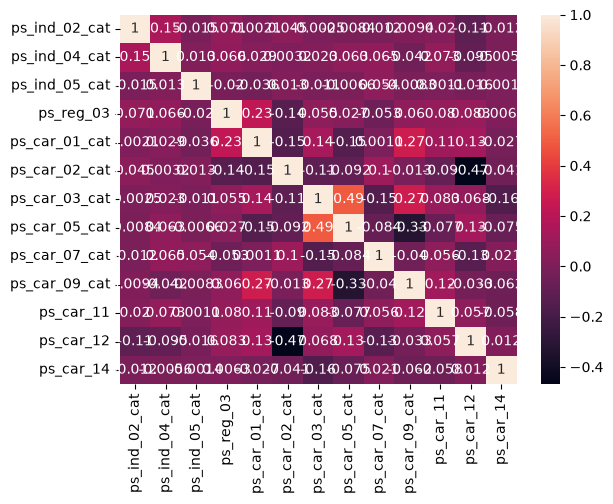

In [86]:
df_null = df_train[missing_value_columns]
df_null_corr_matrix = df_null.corr()

sns.heatmap(df_null_corr_matrix, annot=True)